# Telecom Network Fault Severity and Outage Prediction Using Machine Learning

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle

import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [89]:
train = pd.read_csv(r"C:\Users\Raj\Downloads\Capstone Project 1 Files\Datasets\train.csv")
print("Train Shape:", train.shape)
train.head()

Train Shape: (7381, 3)


,id,location,fault_severity
0,14121,location 118,1
1,9320,location 91,0
2,14394,location 152,1
3,8218,location 931,1
4,14804,location 120,0


##### Supporting Files

In [90]:
event_df    = pd.read_csv(r"C:\Users\Raj\Downloads\Capstone Project 1 Files\Datasets\event_type.csv")
log_df      = pd.read_csv(r"C:\Users\Raj\Downloads\Capstone Project 1 Files\Datasets\log_feature.csv")
resource_df = pd.read_csv(r"C:\Users\Raj\Downloads\Capstone Project 1 Files\Datasets\resource_type.csv")
severity_df = pd.read_csv(r"C:\Users\Raj\Downloads\Capstone Project 1 Files\Datasets\severity_type.csv")

In [91]:
print("Train Shape      :", train.shape)
print("Event Type Shape :", event_df.shape)
print("Log Feature Shape:", log_df.shape)
print("Resource Type    :", resource_df.shape)
print("Severity Type    :", severity_df.shape)

Train Shape      : (7381, 3)
Event Type Shape : (31170, 2)
Log Feature Shape: (58671, 3)
Resource Type    : (21076, 2)
Severity Type    : (18552, 2)


In [92]:
for name, df in [('Train', train), ('Event', event_df), ('Log', log_df), ('Resource', resource_df), ('Severity', severity_df)]:
    print(f"{name}: {df.isnull().sum().sum()} null values")

Train: 0 null values
Event: 0 null values
Log: 0 null values
Resource: 0 null values
Severity: 0 null values


In [93]:
print("Fault Severity Distribution:")
print(train['fault_severity'].value_counts())
print("\n0 = No Fault | 1 = Fault | 2 = Severe Fault")

Fault Severity Distribution:
fault_severity
0    4784
1    1871
2     726
Name: count, dtype: int64

0 = No Fault | 1 = Fault | 2 = Severe Fault


In [94]:
print("Duplicate rows in event_type:", event_df.duplicated().sum())
event_df.head()

Duplicate rows in event_type: 0


,id,event_type
0,6597,event_type 11
1,8011,event_type 15
2,2597,event_type 15
3,5022,event_type 15
4,5022,event_type 11


In [95]:
event_count = event_df.groupby('id')['event_type'].count().reset_index()
event_count.columns = ['id', 'num_event_types']

event_dummies = pd.get_dummies(event_df, columns=['event_type'])
event_agg     = event_dummies.groupby('id').sum().reset_index()

event_agg = event_agg.merge(event_count[['id','num_event_types']], on='id', how='left')

event_agg.head()

,id,event_type_event_type 1,event_type_event_type 10,event_type_event_type 11,event_type_event_type 12,event_type_event_type 13,event_type_event_type 14,event_type_event_type 15,event_type_event_type 17,event_type_event_type 18,...,event_type_event_type 50,event_type_event_type 51,event_type_event_type 52,event_type_event_type 53,event_type_event_type 54,event_type_event_type 6,event_type_event_type 7,event_type_event_type 8,event_type_event_type 9,num_event_types
0,1,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2,3,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [96]:
log_agg = log_df.groupby('id').agg(
    total_log_volume = ('volume', 'sum'),
    num_log_features = ('log_feature', 'count'),
    max_volume       = ('volume', 'max'),
    avg_volume       = ('volume', 'mean')
).reset_index()

log_agg.head()

,id,total_log_volume,num_log_features,max_volume,avg_volume
0,1,5,3,2,1.666667
1,2,5,5,1,1.000000
2,3,2,1,2,2.000000
3,4,3,1,3,3.000000
4,5,17,2,11,8.500000


In [97]:
resource_dummies = pd.get_dummies(resource_df, columns=['resource_type'])
resource_agg     = resource_dummies.groupby('id').sum().reset_index()

resource_agg.head()

,id,resource_type_resource_type 1,resource_type_resource_type 10,resource_type_resource_type 2,resource_type_resource_type 3,resource_type_resource_type 4,resource_type_resource_type 5,resource_type_resource_type 6,resource_type_resource_type 7,resource_type_resource_type 8,resource_type_resource_type 9
0,1,0,0,0,0,0,0,1,0,1,0
1,2,0,0,1,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,1,0
3,4,0,0,1,0,0,0,0,0,0,0
4,5,0,0,1,0,0,0,0,0,0,0


In [98]:
severity_dummies = pd.get_dummies(severity_df, columns=['severity_type'])
severity_agg     = severity_dummies.groupby('id').sum().reset_index()

severity_agg.head()

,id,severity_type_severity_type 1,severity_type_severity_type 2,severity_type_severity_type 3,severity_type_severity_type 4,severity_type_severity_type 5
0,1,1,0,0,0,0
1,2,0,1,0,0,0
2,3,1,0,0,0,0
3,4,0,0,0,1,0
4,5,0,1,0,0,0


In [99]:
df = train.copy()
df = df.merge(event_agg,    on='id', how='left')
df = df.merge(log_agg,      on='id', how='left')
df = df.merge(resource_agg, on='id', how='left')
df = df.merge(severity_agg, on='id', how='left')

print("Master Dataset Shape:", df.shape)
df.head()

Master Dataset Shape: (7381, 76)


,id,location,fault_severity,event_type_event_type 1,event_type_event_type 10,event_type_event_type 11,event_type_event_type 12,event_type_event_type 13,event_type_event_type 14,event_type_event_type 15,...,resource_type_resource_type 5,resource_type_resource_type 6,resource_type_resource_type 7,resource_type_resource_type 8,resource_type_resource_type 9,severity_type_severity_type 1,severity_type_severity_type 2,severity_type_severity_type 3,severity_type_severity_type 4,severity_type_severity_type 5
0,14121,location 118,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,9320,location 91,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,14394,location 152,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,8218,location 931,1,0,0,1,0,0,0,1,...,0,0,0,1,0,1,0,0,0,0
4,14804,location 120,0,0,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0


In [100]:
df.drop(columns=['id'], inplace=True)
print("Shape after dropping id:", df.shape)
df.head()

Shape after dropping id: (7381, 75)


,location,fault_severity,event_type_event_type 1,event_type_event_type 10,event_type_event_type 11,event_type_event_type 12,event_type_event_type 13,event_type_event_type 14,event_type_event_type 15,event_type_event_type 17,...,resource_type_resource_type 5,resource_type_resource_type 6,resource_type_resource_type 7,resource_type_resource_type 8,resource_type_resource_type 9,severity_type_severity_type 1,severity_type_severity_type 2,severity_type_severity_type 3,severity_type_severity_type 4,severity_type_severity_type 5
0,location 118,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,location 91,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,location 152,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,location 931,1,0,0,1,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0
4,location 120,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0


In [101]:
le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])
df.head()

,location,fault_severity,event_type_event_type 1,event_type_event_type 10,event_type_event_type 11,event_type_event_type 12,event_type_event_type 13,event_type_event_type 14,event_type_event_type 15,event_type_event_type 17,...,resource_type_resource_type 5,resource_type_resource_type 6,resource_type_resource_type 7,resource_type_resource_type 8,resource_type_resource_type 9,severity_type_severity_type 1,severity_type_severity_type 2,severity_type_severity_type 3,severity_type_severity_type 4,severity_type_severity_type 5
0,131,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,850,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,163,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,870,1,0,0,1,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0
4,134,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0


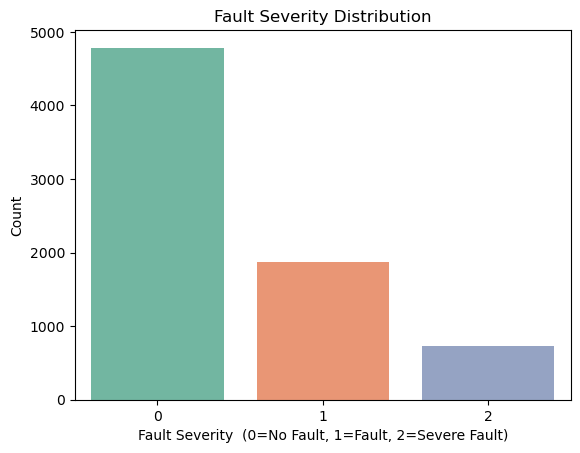

In [102]:
sns.countplot(x='fault_severity', data=df, palette='Set2')
plt.title('Fault Severity Distribution')
plt.xlabel('Fault Severity  (0=No Fault, 1=Fault, 2=Severe Fault)')
plt.ylabel('Count')
plt.show()

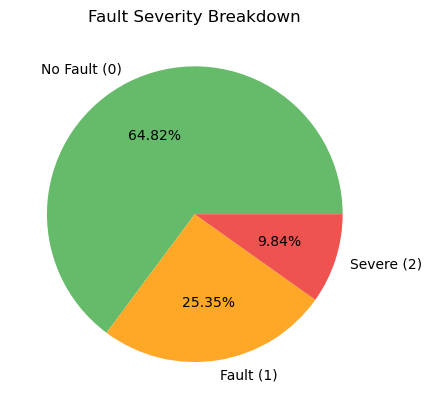

In [103]:
df['fault_severity'].value_counts().plot(
    kind='pie', autopct='%.2f%%',
    labels=['No Fault (0)', 'Fault (1)', 'Severe (2)'],
    colors=['#66bb6a','#ffa726','#ef5350'])
plt.title('Fault Severity Breakdown')
plt.ylabel('')
plt.show()

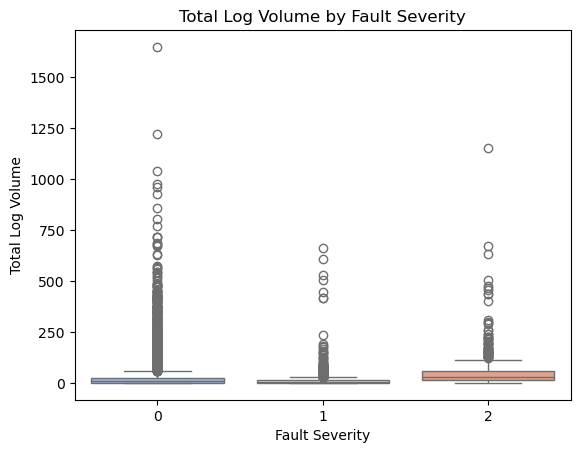

In [104]:
sns.boxplot(x='fault_severity', y='total_log_volume', data=df, palette='coolwarm')
plt.title('Total Log Volume by Fault Severity')
plt.xlabel('Fault Severity')
plt.ylabel('Total Log Volume')
plt.show()

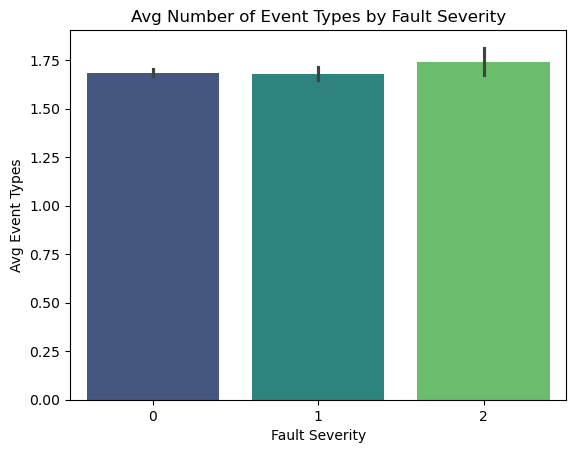

In [105]:
sns.barplot(x='fault_severity', y='num_event_types', data=df, palette='viridis')
plt.title('Avg Number of Event Types by Fault Severity')
plt.xlabel('Fault Severity')
plt.ylabel('Avg Event Types')
plt.show()

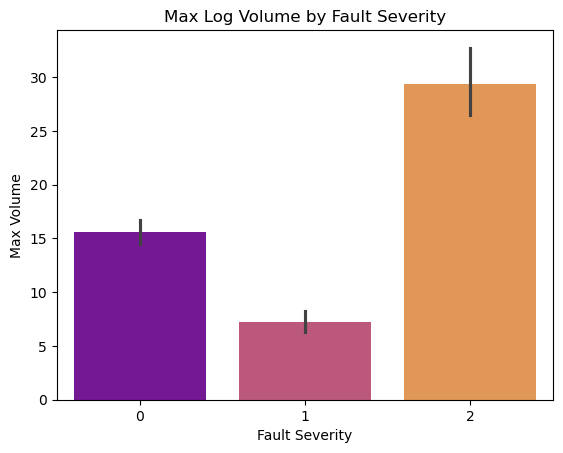

In [106]:
sns.barplot(x='fault_severity', y='max_volume', data=df, palette='plasma')
plt.title('Max Log Volume by Fault Severity')
plt.xlabel('Fault Severity')
plt.ylabel('Max Volume')
plt.show()

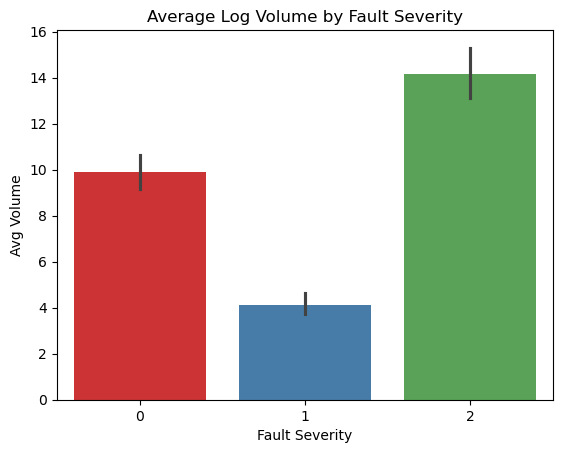

In [107]:
sns.barplot(x='fault_severity', y='avg_volume', data=df, palette='Set1')
plt.title('Average Log Volume by Fault Severity')
plt.xlabel('Fault Severity')
plt.ylabel('Avg Volume')
plt.show()

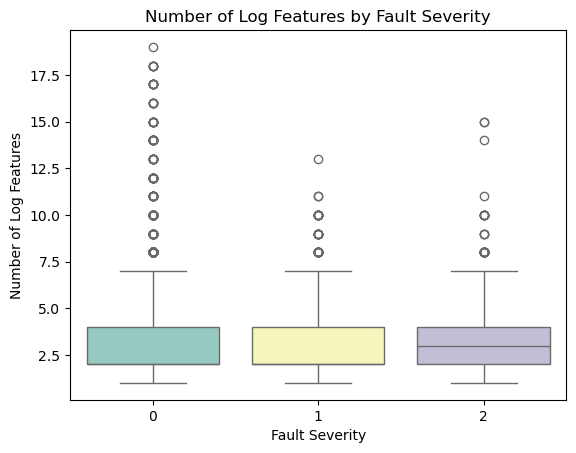

In [108]:
sns.boxplot(x='fault_severity', y='num_log_features', data=df, palette='Set3')
plt.title('Number of Log Features by Fault Severity')
plt.xlabel('Fault Severity')
plt.ylabel('Number of Log Features')
plt.show()

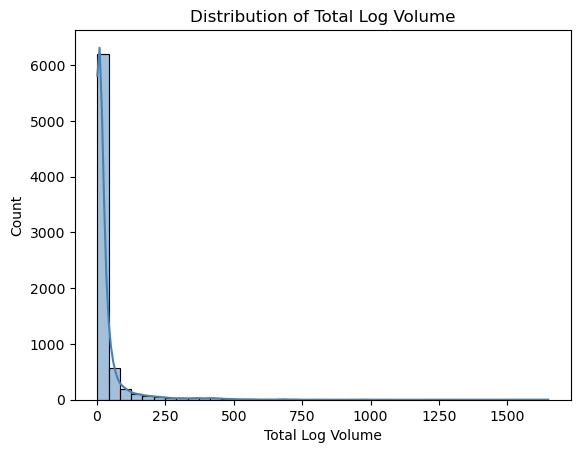

In [109]:
sns.histplot(df['total_log_volume'], kde=True, bins=40, color='steelblue')
plt.title('Distribution of Total Log Volume')
plt.xlabel('Total Log Volume')
plt.show()

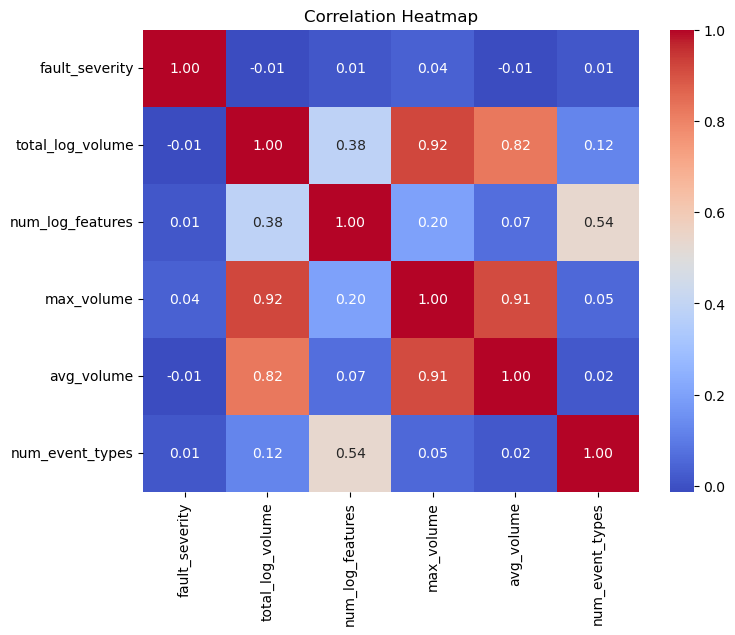

In [110]:
key_cols = ['fault_severity','total_log_volume','num_log_features','max_volume','avg_volume','num_event_types']
plt.figure(figsize=(8,6))
sns.heatmap(df[key_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [111]:
X = df.drop('fault_severity', axis=1)
y = df['fault_severity']

In [112]:
X

,location,event_type_event_type 1,event_type_event_type 10,event_type_event_type 11,event_type_event_type 12,event_type_event_type 13,event_type_event_type 14,event_type_event_type 15,event_type_event_type 17,event_type_event_type 18,...,resource_type_resource_type 5,resource_type_resource_type 6,resource_type_resource_type 7,resource_type_resource_type 8,resource_type_resource_type 9,severity_type_severity_type 1,severity_type_severity_type 2,severity_type_severity_type 3,severity_type_severity_type 4,severity_type_severity_type 5
0,131,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,850,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,163,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,870,0,0,1,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,0
4,134,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,177,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
7377,58,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7378,86,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
7379,656,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0


In [113]:
y

0       1
1       0
2       1
3       1
4       0
       ..
7376    0
7377    0
7378    2
7379    0
7380    0
Name: fault_severity, Length: 7381, dtype: int64

In [114]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=42)

In [115]:
x_train

,location,event_type_event_type 1,event_type_event_type 10,event_type_event_type 11,event_type_event_type 12,event_type_event_type 13,event_type_event_type 14,event_type_event_type 15,event_type_event_type 17,event_type_event_type 18,...,resource_type_resource_type 5,resource_type_resource_type 6,resource_type_resource_type 7,resource_type_resource_type 8,resource_type_resource_type 9,severity_type_severity_type 1,severity_type_severity_type 2,severity_type_severity_type 3,severity_type_severity_type 4,severity_type_severity_type 5
4412,701,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
2526,445,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3819,895,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
6403,132,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3295,456,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,229,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
5226,113,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
5390,306,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
860,96,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [116]:
x_test

,location,event_type_event_type 1,event_type_event_type 10,event_type_event_type 11,event_type_event_type 12,event_type_event_type 13,event_type_event_type 14,event_type_event_type 15,event_type_event_type 17,event_type_event_type 18,...,resource_type_resource_type 5,resource_type_resource_type 6,resource_type_resource_type 7,resource_type_resource_type 8,resource_type_resource_type 9,severity_type_severity_type 1,severity_type_severity_type 2,severity_type_severity_type 3,severity_type_severity_type 4,severity_type_severity_type 5
1103,880,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
2338,897,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
7201,786,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
4013,864,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
2684,686,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6270,786,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
6870,431,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2288,739,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
4987,494,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [117]:
y_train

4412    0
2526    0
3819    0
6403    0
3295    0
       ..
5191    0
5226    0
5390    0
860     0
7270    0
Name: fault_severity, Length: 5904, dtype: int64

In [118]:
y_test

1103    0
2338    0
7201    0
4013    0
2684    0
       ..
6270    0
6870    1
2288    2
4987    0
6258    1
Name: fault_severity, Length: 1477, dtype: int64

### Random Forest

In [119]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [120]:
y_pred_rf = rf.predict(x_test)

In [121]:
accuracy_score(y_test, y_pred_rf)*100

68.11103588354773

In [122]:
print(classification_report(y_test, y_pred_rf, target_names=['No Fault','Fault','Severe Fault']))

              precision    recall  f1-score   support

    No Fault       0.76      0.81      0.79       951
       Fault       0.48      0.41      0.44       376
Severe Fault       0.56      0.52      0.54       150

    accuracy                           0.68      1477
   macro avg       0.60      0.58      0.59      1477
weighted avg       0.67      0.68      0.67      1477



#### Confusion Matrix for Random Forest

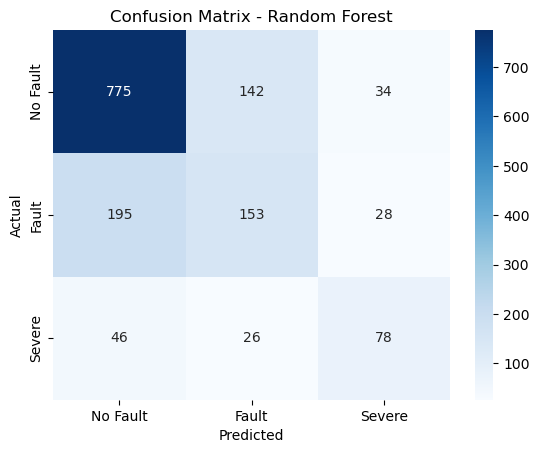

In [123]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fault','Fault','Severe'],
            yticklabels=['No Fault','Fault','Severe'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Gradient Boosting

In [124]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [125]:
y_pred_gb = gb.predict(x_test)

In [126]:
accuracy_score(y_test, y_pred_gb)*100

70.81922816519973

In [127]:
print(classification_report(y_test, y_pred_gb, target_names=['No Fault','Fault','Severe Fault']))

              precision    recall  f1-score   support

    No Fault       0.75      0.89      0.81       951
       Fault       0.57      0.32      0.41       376
Severe Fault       0.57      0.52      0.54       150

    accuracy                           0.71      1477
   macro avg       0.63      0.58      0.59      1477
weighted avg       0.69      0.71      0.68      1477



#### Confusion Matrix for Gradient Boosting

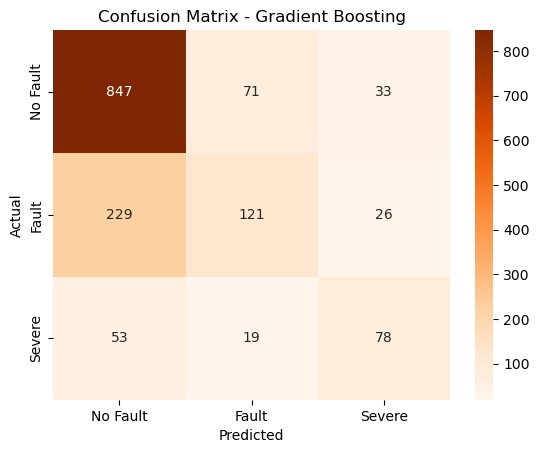

In [128]:
cm2 = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Fault','Fault','Severe'],
            yticklabels=['No Fault','Fault','Severe'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic Regression

In [129]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [130]:
y_pred_lr = lr.predict(x_test)

In [131]:
accuracy_score(y_test, y_pred_lr)*100

65.33513879485443

In [132]:
print(classification_report(y_test, y_pred_lr, target_names=['No Fault','Fault','Severe Fault']))

              precision    recall  f1-score   support

    No Fault       0.69      0.91      0.79       951
       Fault       0.44      0.14      0.22       376
Severe Fault       0.45      0.29      0.35       150

    accuracy                           0.65      1477
   macro avg       0.53      0.45      0.45      1477
weighted avg       0.60      0.65      0.60      1477



#### Confusion Matrix for Logistic Regression

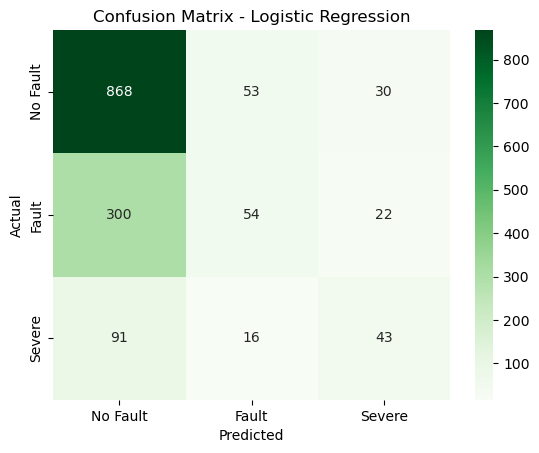

In [133]:
cm3 = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Fault','Fault','Severe'],
            yticklabels=['No Fault','Fault','Severe'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Feature Importance

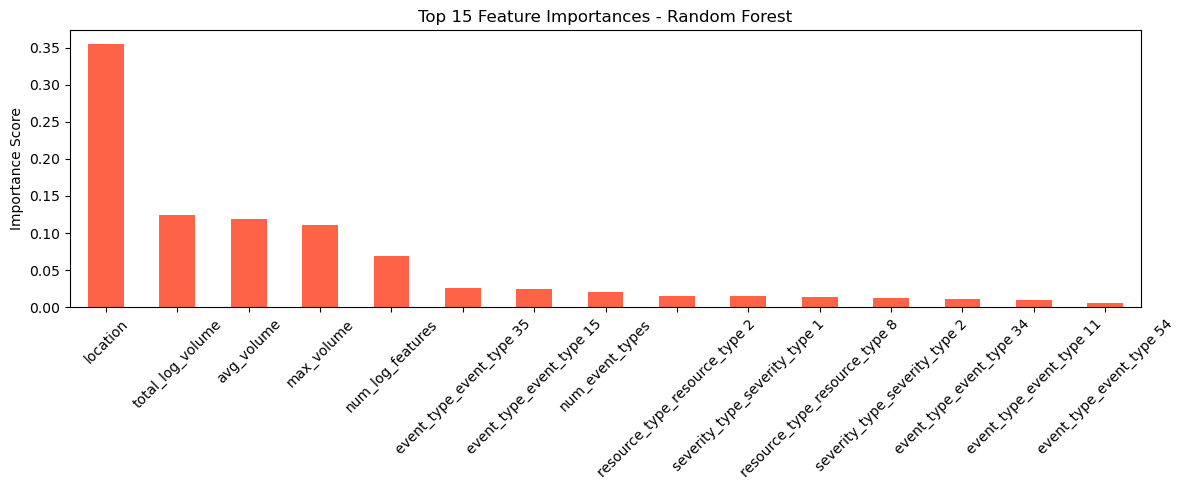

In [134]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(15).plot(
    kind='bar', color='tomato', figsize=(12,5))
plt.title('Top 15 Feature Importances - Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Model Comparison

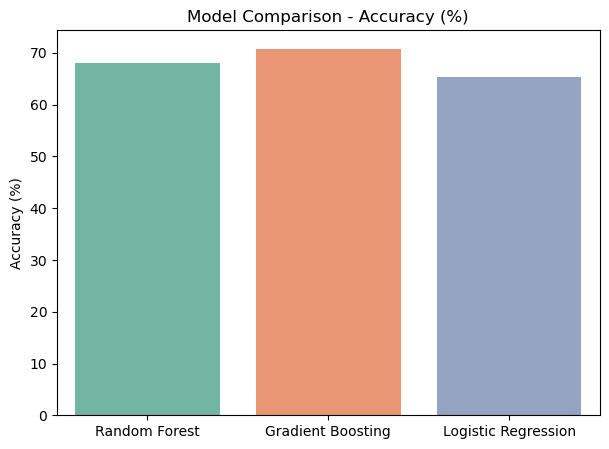

In [135]:
models = ['Random Forest', 'Gradient Boosting', 'Logistic Regression']
scores = [
    accuracy_score(y_test, y_pred_rf)*100,
    accuracy_score(y_test, y_pred_gb)*100,
    accuracy_score(y_test, y_pred_lr)*100
]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=scores, palette='Set2')
plt.title('Model Comparison - Accuracy (%)')
plt.ylabel('Accuracy (%)')
plt.show()

##### Training Simplified Model for Deployment with Top 5 Features

In [136]:
top_features = ['total_log_volume', 'max_volume', 'num_log_features', 'avg_volume', 'num_event_types']

X_simple = X[top_features]
xs_train, xs_test, ys_train, ys_test = train_test_split(X_simple, y, train_size=0.80, random_state=42)

In [142]:
gb_deploy = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_deploy.fit(xs_train, ys_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [144]:
print("Deployment Model Accuracy:", accuracy_score(ys_test, gb_deploy.predict(xs_test))*100)
print()
print(classification_report(ys_test, gb_deploy.predict(xs_test), target_names=['No Fault','Fault','Severe Fault']))

Deployment Model Accuracy: 65.67366283006093

              precision    recall  f1-score   support

    No Fault       0.67      0.97      0.79       951
       Fault       0.48      0.06      0.11       376
Severe Fault       0.55      0.17      0.26       150

    accuracy                           0.66      1477
   macro avg       0.57      0.40      0.39      1477
weighted avg       0.61      0.66      0.56      1477



In [145]:
pickle.dump(gb_deploy, open('Model_CP1.pkl', 'wb'))
print("Model_CP1.pkl saved successfully!")

Model_CP1.pkl saved successfully!
